In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Fear/Greed Index load:
fg =pd.read_csv("Data science intern project/fear_greed_index.csv")

# Trader data load:
trader =pd.read_csv("Data science intern project/historical_data.csv")


In [3]:
print("Fear Greed Shape:", fg.shape)
print("Trader Shape:", trader.shape)


Fear Greed Shape: (2644, 4)
Trader Shape: (211224, 16)


In [4]:
fg.head()



,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
trader.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## Part A — Data Preparation

In [6]:
print("Fear Greed Missing Values:")
print(fg.isnull().sum())

print("\nTrader Missing Values:")
print(trader.isnull().sum())




Fear Greed Missing Values:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Trader Missing Values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [7]:
print("Fear Greed Duplicates:", fg.duplicated().sum())
print("Trader Duplicates:", trader.duplicated().sum())

Fear Greed Duplicates: 0
Trader Duplicates: 0


In [8]:
# Trader file extract date
trader['date'] = pd.to_datetime(trader['Timestamp IST'], 
                                format='%d-%m-%Y %H:%M').dt.date

# Fear/Greed file extract datetime
fg['date'] = pd.to_datetime(fg['date']).dt.date

print("Trader date sample:")
print(trader['date'].head())

print("\nFear Greed date sample:")
print(fg['date'].head())


Trader date sample:
0    2024-12-02
1    2024-12-02
2    2024-12-02
3    2024-12-02
4    2024-12-02
Name: date, dtype: object

Fear Greed date sample:
0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: date, dtype: object


In [9]:
print("Trader Date Range:")
print("Start:", trader['date'].min())
print("End:", trader['date'].max())

print("\nFear Greed Date Range:")
print("Start:", fg['date'].min())
print("End:", fg['date'].max())

Trader Date Range:
Start: 2023-05-01
End: 2025-05-01

Fear Greed Date Range:
Start: 2018-02-01
End: 2025-05-02


In [10]:
# merged both files
merged = pd.merge(trader, fg, on='date', how='left')

print("Merged Shape:", merged.shape)
print("\nMerged Columns:", merged.columns.tolist())
merged.head()

Merged Shape: (211224, 20)

Merged Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'date', 'timestamp', 'value', 'classification']


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


In [11]:
print(merged[merged['classification'].isnull()])

                                        Account   Coin  Execution Price  \
727  0x72c6a4624e1dffa724e6d00d64ceae698af892a0  EIGEN           2.8330   
728  0x72c6a4624e1dffa724e6d00d64ceae698af892a0  EIGEN           2.7110   
729  0x72c6a4624e1dffa724e6d00d64ceae698af892a0  EIGEN           2.5889   
730  0x72c6a4624e1dffa724e6d00d64ceae698af892a0  EIGEN           2.5889   
731  0x72c6a4624e1dffa724e6d00d64ceae698af892a0  EIGEN           2.5889   
732  0x72c6a4624e1dffa724e6d00d64ceae698af892a0  EIGEN           2.5889   

     Size Tokens  Size USD Side     Timestamp IST  Start Position  \
727     10000.00  28330.00  BUY  26-10-2024 04:44       -32797.51   
728     10797.51  29272.05  BUY  26-10-2024 04:52       -22797.51   
729      6908.33  17884.98  BUY  26-10-2024 04:52       -12000.00   
730       529.39   1370.54  BUY  26-10-2024 04:52        -5091.67   
731        38.65    100.06  BUY  26-10-2024 04:52        -4562.28   
732      4523.63  11711.23  BUY  26-10-2024 04:53        -45

In [12]:
fg[fg['date'].astype(str).str.contains('2024-10')]

,timestamp,value,classification,date
2431,1727760600,50,Neutral,2024-10-01
2432,1727847000,42,Fear,2024-10-02
2433,1727933400,37,Fear,2024-10-03
2434,1728019800,41,Fear,2024-10-04
2435,1728106200,49,Neutral,2024-10-05
2436,1728192600,50,Neutral,2024-10-06
2437,1728279000,50,Neutral,2024-10-07
2438,1728365400,49,Neutral,2024-10-08
2439,1728451800,49,Neutral,2024-10-09
2440,1728538200,39,Fear,2024-10-10


In [14]:
merged['classification'] = merged['classification'].ffill()
merged['value'] = merged['value'].ffill()

# Check 
print("Missing after fill:", merged['classification'].isnull().sum())

Missing after fill: 0


In [15]:
sentiment_pnl = merged.groupby('classification')['Closed PnL'].agg(['sum','mean','count']).reset_index()
sentiment_pnl.columns = ['Sentiment', 'Total PnL', 'Avg PnL', 'Trade Count']
print(sentiment_pnl)

       Sentiment     Total PnL    Avg PnL  Trade Count
0   Extreme Fear  7.391102e+05  34.537862        21400
1  Extreme Greed  2.715171e+06  67.892861        39992
2           Fear  3.357155e+06  54.290400        61837
3          Greed  2.192601e+06  43.582684        50309
4        Neutral  1.292921e+06  34.307718        37686


In [16]:
pd.options.display.float_format = '{:,.2f}'.format
print(sentiment_pnl)

       Sentiment    Total PnL  Avg PnL  Trade Count
0   Extreme Fear   739,110.25    34.54        21400
1  Extreme Greed 2,715,171.31    67.89        39992
2           Fear 3,357,155.44    54.29        61837
3          Greed 2,192,601.27    43.58        50309
4        Neutral 1,292,920.68    34.31        37686


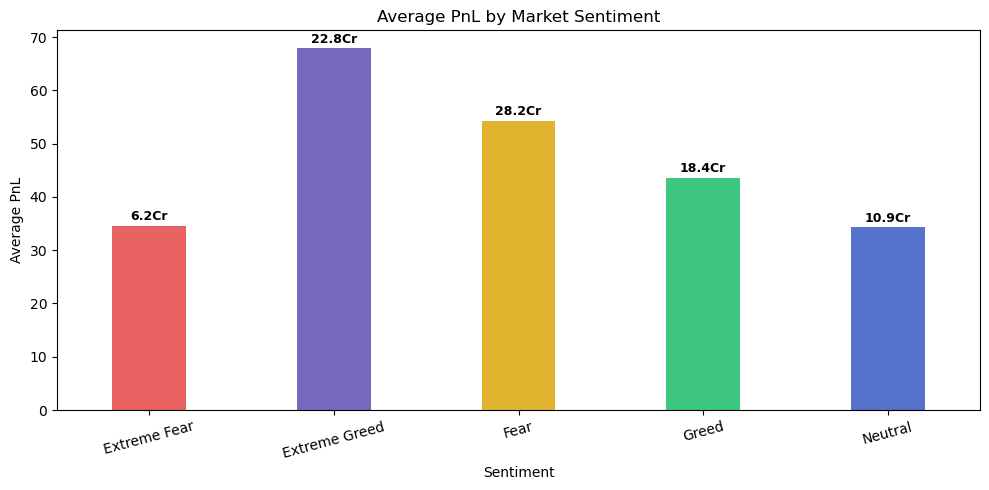

In [17]:
def format_amount(amount):
    usd_to_inr = 84
    inr = amount * usd_to_inr
    if inr >= 10_000_000:      # 1 Crore+
        return f"{inr/10_000_000:.1f}Cr"
    elif inr >= 100_000:        # 1 Lakh+
        return f"{inr/100_000:.1f}L"
    elif inr >= 1_000:          # 1 Thousand+
        return f"{inr/1_000:.1f}K"
    else:
        return f"{inr:.0f}"

plt.figure(figsize=(10,5))
ax = sns.barplot(data=sentiment_pnl, x='Sentiment', y='Avg PnL', 
            hue='Sentiment', 
            palette=['#FF4B4B','#6A5ACD','#FFC312','#26de81','#4169E1'], 
            legend=False,
            width=0.4)  # thinner bars

for i, row in sentiment_pnl.iterrows():
    ax.text(i, row['Avg PnL'] + 0.5, 
            format_amount(row['Total PnL']), 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title('Average PnL by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average PnL')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [18]:
# Win rate = PnL > 0  percentage
merged['is_win'] = merged['Closed PnL'] > 0

win_rate = merged.groupby('classification')['is_win'].mean().reset_index()
win_rate.columns = ['Sentiment', 'Win Rate']
win_rate['Win Rate'] = win_rate['Win Rate'] * 100  # percentage mein
print(win_rate)

       Sentiment  Win Rate
0   Extreme Fear     37.06
1  Extreme Greed     46.49
2           Fear     42.08
3          Greed     38.49
4        Neutral     39.70


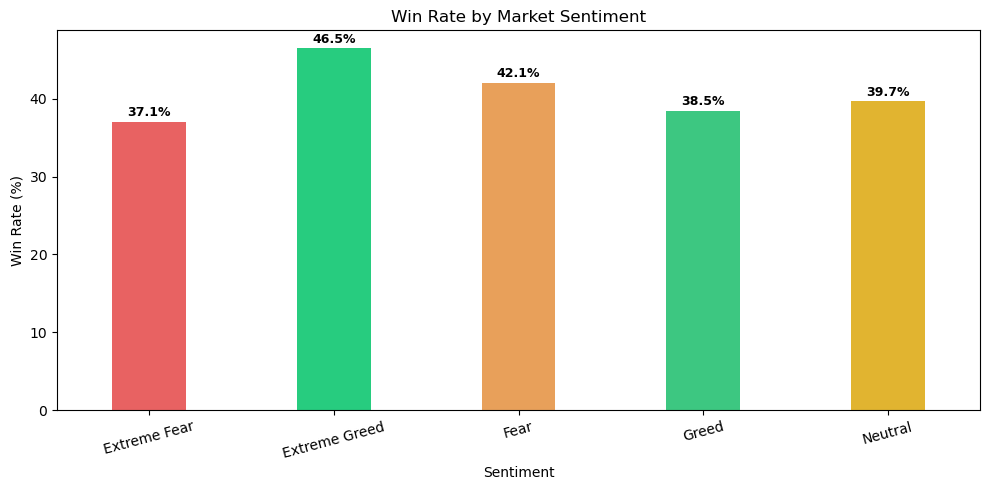

In [19]:
plt.figure(figsize=(10,5))
ax = sns.barplot(data=win_rate, x='Sentiment', y='Win Rate',
            hue='Sentiment',
            palette=['#FF4B4B','#0be881','#FF9F43','#26de81','#FFC312'],
            legend=False,
            width=0.4)

for i, row in win_rate.iterrows():
    ax.text(i, row['Win Rate'] + 0.3,
            f"{row['Win Rate']:.1f}%",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title('Win Rate by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Win Rate (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

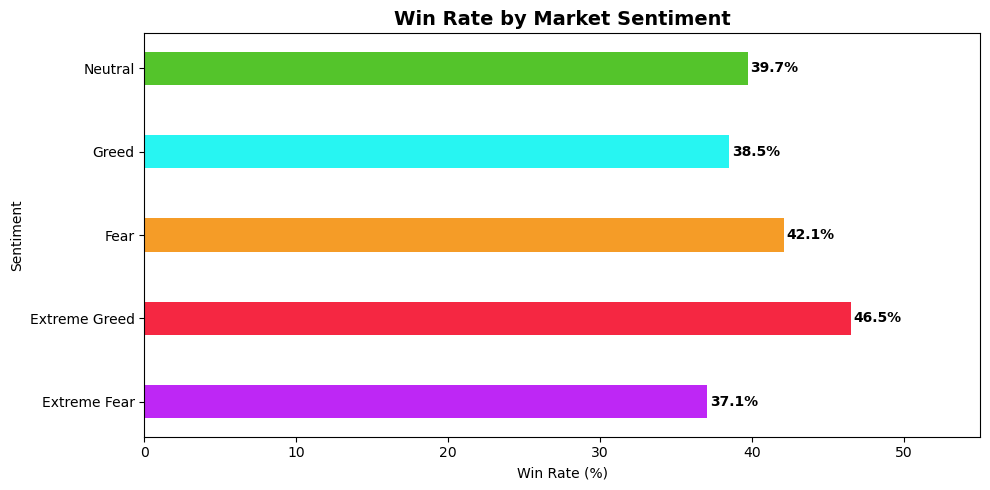

In [48]:
colors = ['#BE27F5','#F52742','#F59C27','#27F5F2','#54C42B']

plt.figure(figsize=(10,5))
bars = plt.barh(win_rate['Sentiment'], win_rate['Win Rate'], 
                color=colors, height=0.4)

# Data labels
for bar, val in zip(bars, win_rate['Win Rate']):
    plt.text(val + 0.2, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}%",
             va='center', fontsize=10, fontweight='bold')

plt.title('Win Rate by Market Sentiment', fontsize=14, fontweight='bold')
plt.xlabel('Win Rate (%)')
plt.ylabel('Sentiment')
plt.xlim(0, 55)
plt.tight_layout()
plt.show()

In [50]:
trade_freq = merged.groupby('classification').size().reset_index()
trade_freq.columns = ['Sentiment', 'Trade Count']
print(trade_freq)

       Sentiment  Trade Count
0   Extreme Fear        21400
1  Extreme Greed        39992
2           Fear        61837
3          Greed        50309
4        Neutral        37686


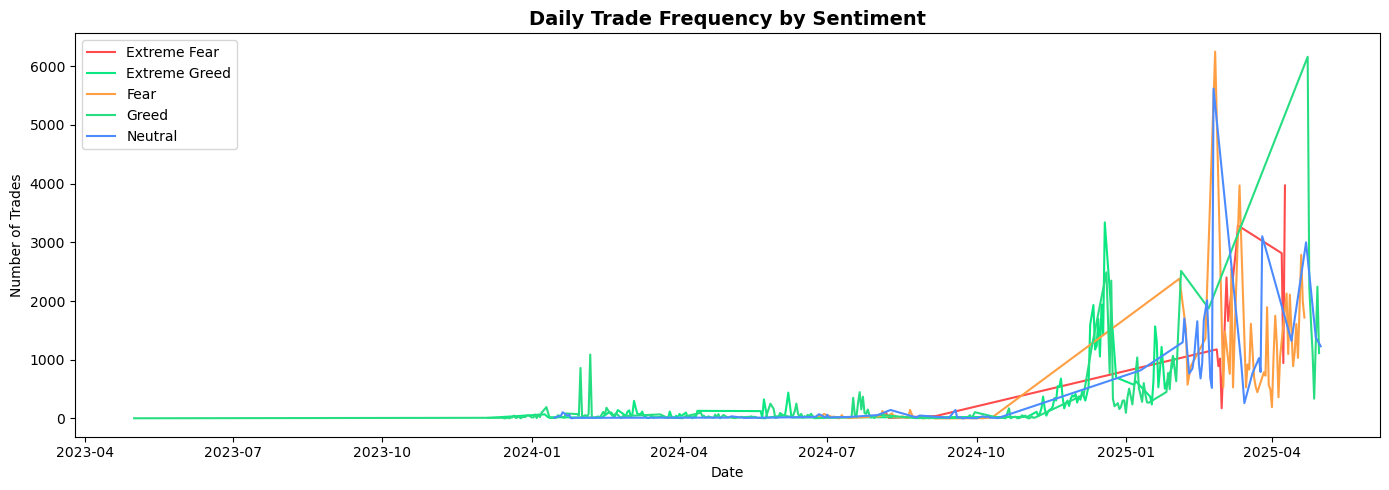

In [52]:
# Daily trade count Chart -1
daily_trades = merged.groupby(['date', 'classification']).size().reset_index()
daily_trades.columns = ['date', 'Sentiment', 'Trade Count']
daily_trades['date'] = pd.to_datetime(daily_trades['date'])

plt.figure(figsize=(14,5))
colors_map = {
    'Extreme Fear': '#FF4B4B',
    'Extreme Greed': '#0be881',
    'Fear': '#FF9F43',
    'Greed': '#26de81',
    'Neutral': '#4B8BFF'
}

for sentiment, group in daily_trades.groupby('Sentiment'):
    plt.plot(group['date'], group['Trade Count'], 
             label=sentiment, 
             color=colors_map[sentiment],
             linewidth=1.5)

plt.title('Daily Trade Frequency by Sentiment', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Number of Trades')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

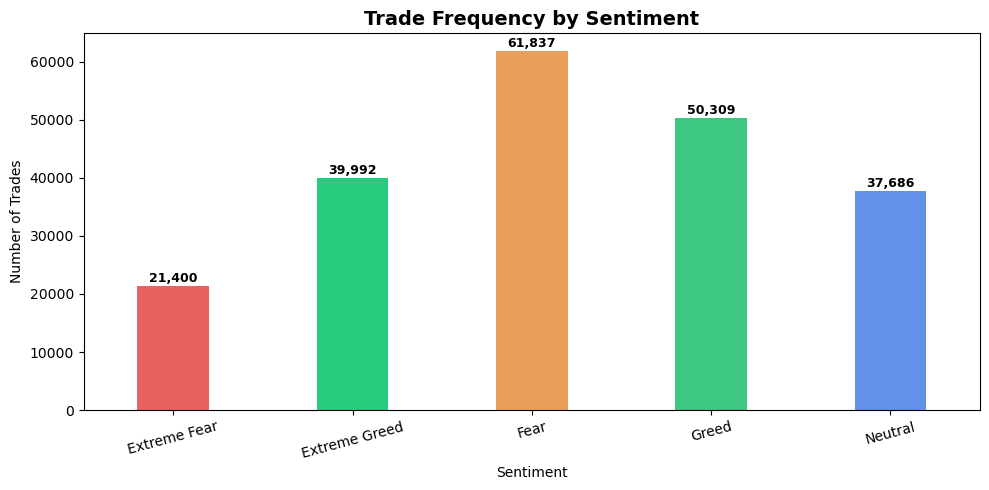

In [57]:
## Chart -2
plt.figure(figsize=(10,5)) 
ax = sns.barplot(data=trade_freq, x='Sentiment', y='Trade Count',
            hue='Sentiment',
            palette=['#FF4B4B','#0be881','#FF9F43','#26de81','#4B8BFF'],
            legend=False,
            width=0.4)

for i, row in trade_freq.iterrows():
    ax.text(i, row['Trade Count'] + 200,
            f"{int(row['Trade Count']):,}",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title('Trade Frequency by Sentiment', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Number of Trades')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [59]:
# Long vs Short count 
merged['is_long'] = merged['Direction'].str.contains('Buy|Long', case=False)

long_short = merged.groupby('classification')['is_long'].mean().reset_index()
long_short.columns = ['Sentiment', 'Long Ratio']
long_short['Long Ratio'] = long_short['Long Ratio'] * 100
long_short['Short Ratio'] = 100 - long_short['Long Ratio']
print(long_short)

       Sentiment  Long Ratio  Short Ratio
0   Extreme Fear       65.72        34.28
1  Extreme Greed       46.60        53.40
2           Fear       61.97        38.03
3          Greed       42.27        57.73
4        Neutral       61.37        38.63


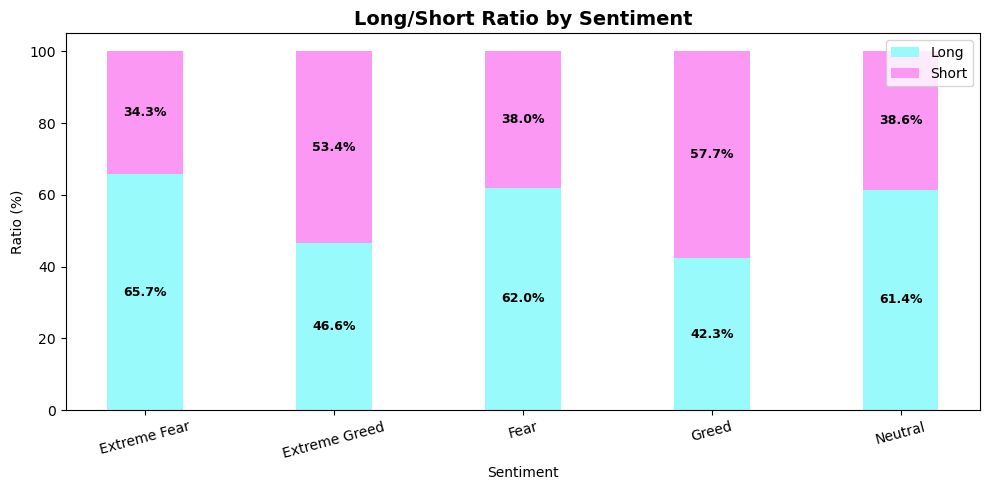

In [102]:
plt.figure(figsize=(10,5))

x = range(len(long_short))
plt.bar(x, long_short['Long Ratio'], 
        color='#98FAFA', label='Long', width=0.4)
plt.bar(x, long_short['Short Ratio'], 
        bottom=long_short['Long Ratio'],
        color='#FA98F4', label='Short', width=0.4)

# Labels
for i, row in long_short.iterrows():
    plt.text(i, row['Long Ratio']/2, f"{row['Long Ratio']:.1f}%",
             ha='center', va='center', fontsize=9, 
             fontweight='bold', color='black')
    plt.text(i, row['Long Ratio'] + row['Short Ratio']/2, 
             f"{row['Short Ratio']:.1f}%",
             ha='center', va='center', fontsize=9, 
             fontweight='bold', color='black')

plt.xticks(x, long_short['Sentiment'], rotation=15)
plt.title('Long/Short Ratio by Sentiment', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Ratio (%)')
plt.legend()
plt.tight_layout()
plt.show()

## Part B — Analysis: Trader Behavior vs Market Sentiment


In [71]:
print(merged['Start Position'].describe())

count       211,224.00
mean        -29,946.25
std         673,807.42
min     -14,334,629.00
25%            -376.23
50%              84.73
75%           9,337.28
max      30,509,482.00
Name: Start Position, dtype: float64


In [72]:
print(merged['Size USD'].describe())

count     211,224.00
mean        5,639.45
std        36,575.14
min             0.00
25%           193.79
50%           597.05
75%         2,058.96
max     3,921,430.72
Name: Size USD, dtype: float64


In [79]:
segment_perf = merged.groupby(['Trade Size Segment', 'classification'], observed=True).agg(
    Avg_PnL=('Closed PnL', 'mean'),
    Win_Rate=('is_win', 'mean'),
    Trade_Count=('Closed PnL', 'count')
).reset_index()

segment_perf['Win_Rate'] = segment_perf['Win_Rate'] * 100
print(segment_perf)

   Trade Size Segment classification  Avg_PnL  Win_Rate  Trade_Count
0                 Low   Extreme Fear    -0.60     30.54         4136
1                 Low  Extreme Greed     5.10     53.17        12962
2                 Low           Fear     1.38     41.56        12857
3                 Low          Greed     2.08     41.86        12846
4                 Low        Neutral     0.63     39.67         9744
5              Medium   Extreme Fear     4.62     39.08        11485
6              Medium  Extreme Greed    28.14     45.00        18187
7              Medium           Fear    13.14     42.27        32187
8              Medium          Greed    13.64     36.81        24676
9              Medium        Neutral     9.66     38.55        19275
10               High   Extreme Fear   119.15     37.72         5779
11               High  Extreme Greed   242.01     39.84         8831
12               High           Fear   173.80     42.13        16782
13               High          Gre

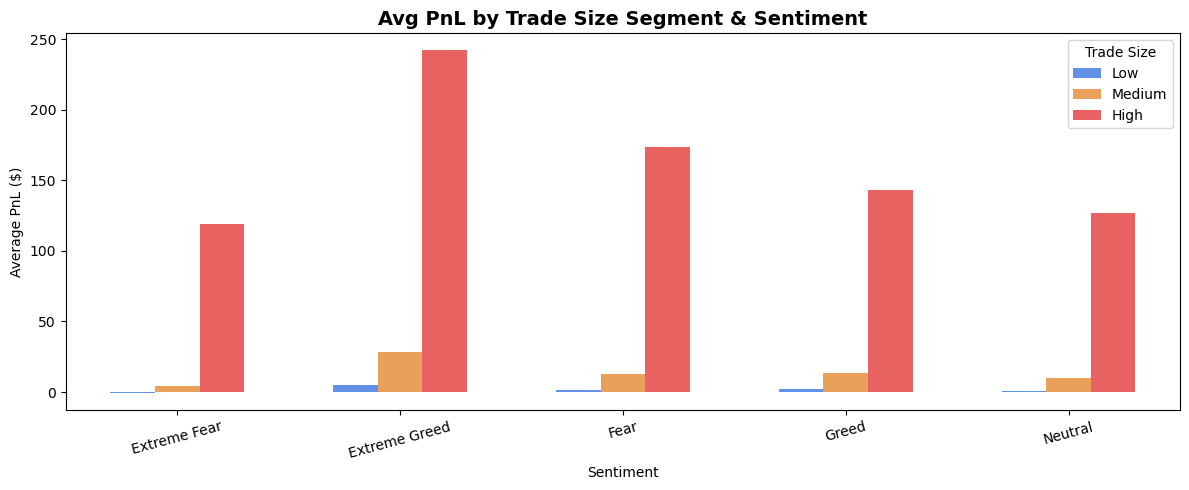

In [81]:
plt.figure(figsize=(12,5))
sns.barplot(data=segment_perf, x='classification', y='Avg_PnL',
            hue='Trade Size Segment',
            palette=['#4B8BFF','#FF9F43','#FF4B4B'],
            width=0.6)

plt.title('Avg PnL by Trade Size Segment & Sentiment', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Average PnL ($)')
plt.xticks(rotation=15)
plt.legend(title='Trade Size')
plt.tight_layout()
plt.show()

In [83]:
# Daily Trader Traides
trader_freq = merged.groupby('Account').size().reset_index()
trader_freq.columns = ['Account', 'Total Trades']

# Segments 
trader_freq['Frequency Segment'] = pd.cut(trader_freq['Total Trades'],
    bins=[0, 50, 200, float('inf')],
    labels=['Infrequent', 'Moderate', 'Frequent'])

print(trader_freq['Frequency Segment'].value_counts())

Frequency Segment
Frequent      32
Infrequent     0
Moderate       0
Name: count, dtype: int64


In [85]:
print(trader_freq['Total Trades'].describe())

count       32.00
mean     6,600.75
std      8,250.37
min        332.00
25%      1,381.75
50%      3,699.00
75%      8,862.50
max     40,184.00
Name: Total Trades, dtype: float64


In [87]:
trader_freq['Frequency Segment'] = pd.cut(trader_freq['Total Trades'],
    bins=[0, 1381, 8862, float('inf')],
    labels=['Infrequent', 'Moderate', 'Frequent'])

print(trader_freq['Frequency Segment'].value_counts())

Frequency Segment
Moderate      16
Infrequent     8
Frequent       8
Name: count, dtype: int64


In [89]:
# Segment info trader data mein merge karo
merged2 = merged.merge(trader_freq[['Account', 'Frequency Segment']], 
                       on='Account', how='left')

# Har segment ka performance
freq_perf = merged2.groupby('Frequency Segment', observed=True).agg(
    Avg_PnL=('Closed PnL', 'mean'),
    Win_Rate=('is_win', 'mean'),
    Total_Trades=('Closed PnL', 'count')
).reset_index()

freq_perf['Win_Rate'] = freq_perf['Win_Rate'] * 100
print(freq_perf)

  Frequency Segment  Avg_PnL  Win_Rate  Total_Trades
0        Infrequent   173.04     43.38          5256
1          Moderate    62.14     38.25         63816
2          Frequent    38.14     42.33        142152


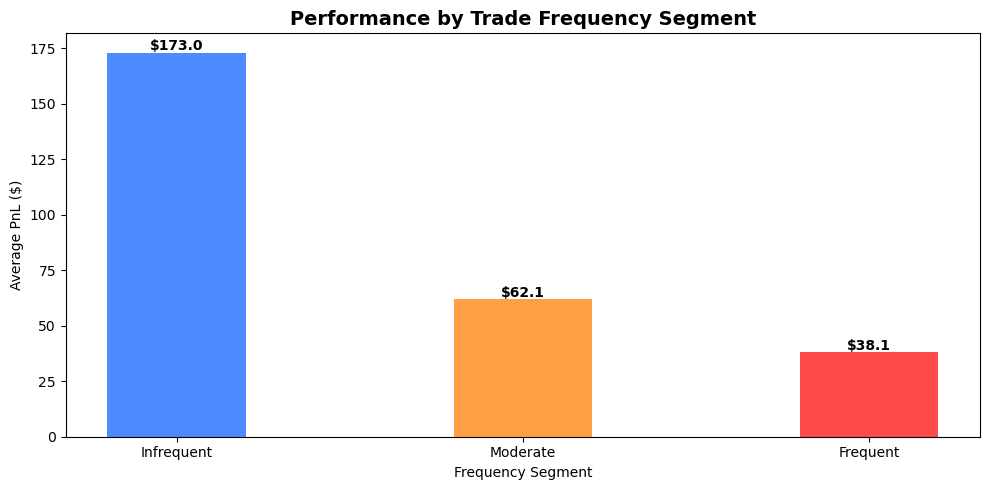

In [91]:
fig, ax1 = plt.subplots(figsize=(10,5))

x = range(len(freq_perf))
bars = ax1.bar(x, freq_perf['Avg_PnL'],
               color=['#4B8BFF','#FF9F43','#FF4B4B'],
               width=0.4)

# Data labels
for i, row in freq_perf.iterrows():
    ax1.text(i, row['Avg_PnL'] + 1,
             f"${row['Avg_PnL']:.1f}",
             ha='center', fontsize=10, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(freq_perf['Frequency Segment'])
ax1.set_ylabel('Average PnL ($)')
ax1.set_xlabel('Frequency Segment')
plt.title('Performance by Trade Frequency Segment', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [93]:
#  traders  overall PnL 
trader_pnl = merged.groupby('Account').agg(
    Total_PnL=('Closed PnL', 'sum'),
    Avg_PnL=('Closed PnL', 'mean'),
    Win_Rate=('is_win', 'mean'),
    Total_Trades=('Closed PnL', 'count')
).reset_index()

trader_pnl['Win_Rate'] = trader_pnl['Win_Rate'] * 100

# Segments banao
trader_pnl['Performance Segment'] = pd.cut(trader_pnl['Win_Rate'],
    bins=[0, 40, 55, 100],
    labels=['Loser', 'Moderate', 'Winner'])

print(trader_pnl['Performance Segment'].value_counts())

Performance Segment
Loser       16
Moderate    14
Winner       2
Name: count, dtype: int64


In [95]:
# Segment info merge 
merged3 = merged.merge(trader_pnl[['Account', 'Performance Segment']], 
                       on='Account', how='left')

# Performance by segment and sentiment
winner_perf = merged3.groupby(['Performance Segment', 'classification'], 
                               observed=True).agg(
    Avg_PnL=('Closed PnL', 'mean'),
    Win_Rate=('is_win', 'mean')
).reset_index()

winner_perf['Win_Rate'] = winner_perf['Win_Rate'] * 100
print(winner_perf)

   Performance Segment classification  Avg_PnL  Win_Rate
0                Loser   Extreme Fear    67.57     33.42
1                Loser  Extreme Greed    78.67     33.80
2                Loser           Fear   102.49     36.42
3                Loser          Greed    41.05     29.58
4                Loser        Neutral    36.08     32.86
5             Moderate   Extreme Fear    19.38     37.47
6             Moderate  Extreme Greed    57.89     51.10
7             Moderate           Fear    34.37     43.19
8             Moderate          Greed    46.22     45.57
9             Moderate        Neutral    35.49     43.52
10              Winner   Extreme Fear    76.98     90.03
11              Winner  Extreme Greed    62.92     83.36
12              Winner           Fear    19.11     76.11
13              Winner          Greed    51.40     81.36
14              Winner        Neutral    -1.81     71.32


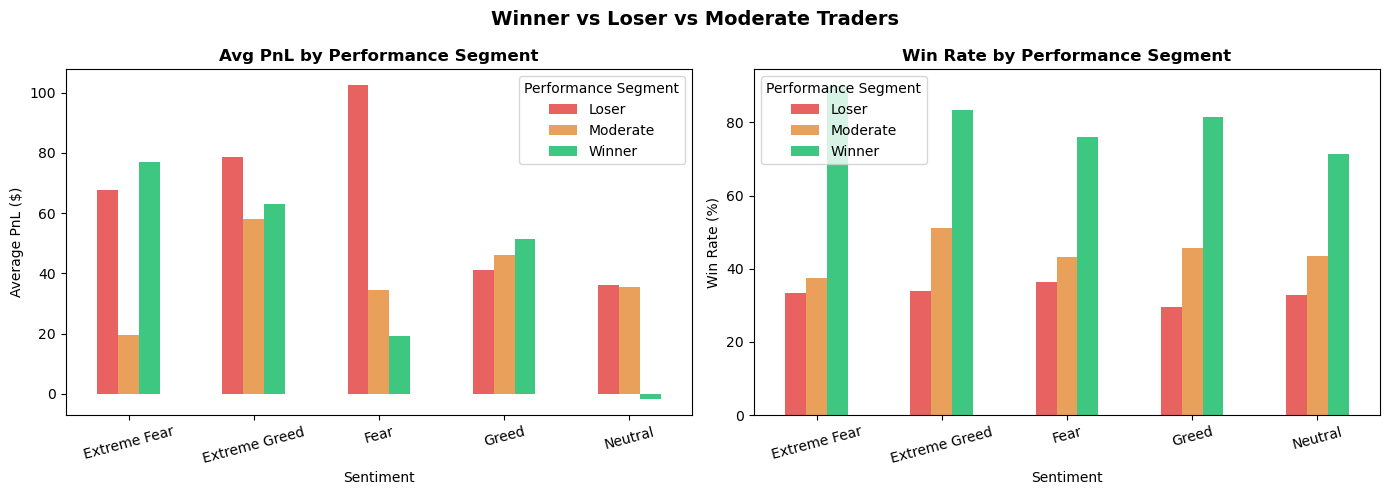

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Chart 1 - Avg PnL
sns.barplot(data=winner_perf, x='classification', y='Avg_PnL',
            hue='Performance Segment',
            palette=['#FF4B4B','#FF9F43','#26de81'],
            ax=axes[0], width=0.5)
axes[0].set_title('Avg PnL by Performance Segment', fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Average PnL ($)')
axes[0].tick_params(axis='x', rotation=15)

# Chart 2 - Win Rate
sns.barplot(data=winner_perf, x='classification', y='Win_Rate',
            hue='Performance Segment',
            palette=['#FF4B4B','#FF9F43','#26de81'],
            ax=axes[1], width=0.5)
axes[1].set_title('Win Rate by Performance Segment', fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Win Rate (%)')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Winner vs Loser vs Moderate Traders', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

###  Part C — 2 Actionable Strategie



### Strategy 1: Trade Big During Extreme Greed
**Finding:** High trade size traders earned an average of $242 during Extreme Greed 
days — the highest across all sentiment categories.

**Rule:** When the Fear/Greed Index shows Extreme Greed (value 75+), 
increase your position size. Market momentum is in your favor.

**Evidence:** 
- High segment Avg PnL = $242 (Extreme Greed) vs $119 (Extreme Fear)
- Win Rate = 39.8% during Extreme Greed for High traders

---

### Strategy 2: Less is More — Trade Selectively
**Finding:** Infrequent traders (fewer trades) earned 4.5x more per trade 
than Frequent traders.

**Rule:** Avoid overtrading. Focus only on high-confidence setups. 
Quality of trades matters more than quantity.

**Evidence:**
- Infrequent traders Avg PnL = $173
- Frequent traders Avg PnL = $38
- More trades = more noise = lower returns